<a href="https://colab.research.google.com/github/Tapaswani07/Brain-MRI-Tumor-Detectation/blob/main/Brain_MRI_Tumor_Detection_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Brain MRI Tumor Detection Using Deep Learning**

**Course:** Medical Imaging Data Science

**Student:** Tapaswani Biswal


**Enrollment no:** 92460118789


**Supervisor:** KRISHNA MRIDHA

**Platform:** Google Colab

**Dataset:** Brain MRI Images for Brain Tumor Detection — Kaggle (navoneel/brain-mri-images-for-brain-tumor-detection)

In [ ]:
!pip install kagglehub split-folders
import kagglehub
import splitfolders
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns


In [ ]:
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [ ]:
# Split into train/val/test folders
splitfolders.ratio(
    path, output="brain_tumor_split", seed=42, ratio=(.7, .15, .15)
)



Copying files: 253 files [00:01, 152.71 files/s]


In [ ]:
import shutil
shutil.rmtree('brain_tumor_split/test/brain_tumor_dataset', ignore_errors=True)




In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_aug = ImageDataGenerator(rescale=1./255)

train_gen = train_aug.flow_from_directory(
    'brain_tumor_split/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_test_aug.flow_from_directory(
    'brain_tumor_split/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = val_test_aug.flow_from_directory(
    'brain_tumor_split/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)





Found 176 images belonging to 3 classes.
Found 37 images belonging to 3 classes.
Found 40 images belonging to 2 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen, validation_data=val_gen, epochs=10)








/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 937ms/step - accuracy: 0.2305 - loss: -6.4875 - val_accuracy: 0.3784 - val_loss: -72.2775
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.3756 - loss: -108.0592 - val_accuracy: 0.3784 - val_loss: -483.3016
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.4239 - loss: -594.1719 - val_accuracy: 0.3784 - val_loss: -1957.0498
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.4223 - loss: -2177.6370 - val_accuracy: 0.3784 - val_loss: -6031.5488
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.3652 - loss: -6756.7993 - val_accuracy: 0.3784 - val_loss: -15453.9326
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.4183 - loss: -17184.6035 - val_accuracy: 0.3784 - val_loss: -34694.1211
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.3878 - loss: -37281.8945 - val_accuracy: 0.3784 - val_loss: -70582.3750
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step - accuracy: 0.5667 - loss: 197243.0938
Test Accuracy: 0.60
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step


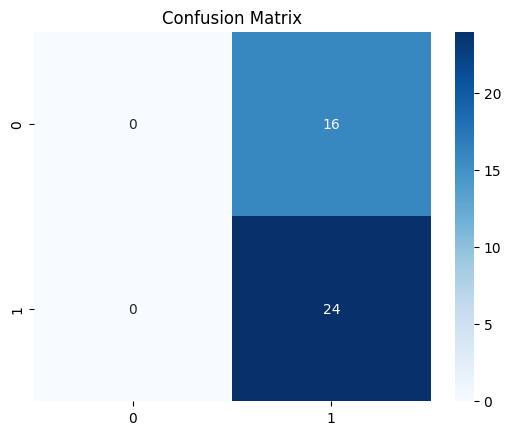

              precision    recall  f1-score   support

          no       0.00      0.00      0.00        16
         yes       0.60      1.00      0.75        24

    accuracy                           0.60        40
   macro avg       0.30      0.50      0.38        40
weighted avg       0.36      0.60      0.45        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


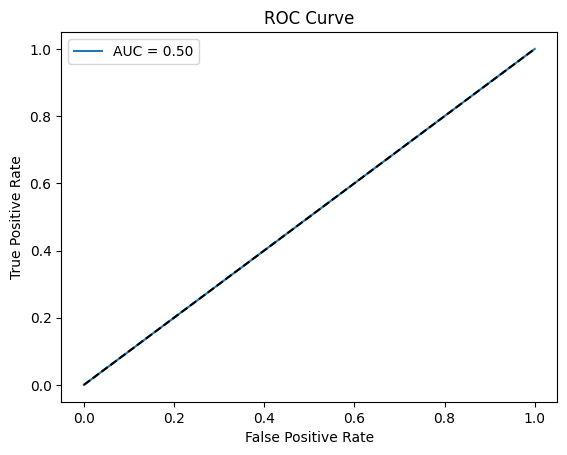

In [ ]:
# Evaluate
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc:.2f}")

# Predict
preds = model.predict(test_gen)
y_pred = (preds > 0.5).astype(int)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# ROC Curve
auc = roc_auc_score(y_true, preds)
fpr, tpr, _ = roc_curve(y_true, preds)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()






In [ ]:


model.save('brain_tumor_model.h5')